# D-SUP-01 — RF embedding signal: interaction semantics vs business/domain semantics

**inquiry_kind**: `DIRECTOR_SUPPLEMENTAL` · **child_id** `D-SUP-01` · **depends_on** `RQ-D14`

| 항목 | 값 |
|---|---|
| research_question | RF embedding signal 은 representative interaction semantics 를 재고 있는가, business/domain semantics 를 재고 있는가 (falsification) |
| hypothesis_id (층1, 사전등록) | `H-SUP01-SIGNAL-SOURCE` |
| hypothesis_id (층2, 헤드라인) | `H-SUP01-SIGNAL-SOURCE-PRIORFREE` |
| competing hypotheses | INTERACTION / DOMAIN / BOTH / INSEPARABLE |
| grain | target state (`in_mart==1`), 1행 = 1 web target |
| n | expected 56 / observed 56 / complete-case 50 |
| strata | FUNCTIONAL_LANDING 27 · UNDETERMINED 26 · CORPORATE_OR_APP_LANDING 3 |
| seed | 20260827 |
| model | `BAAI/bge-m3` 단일, frozen SSOT prototype 3세트, 오프라인 |

아래 첫 코드 셀이 input snapshot sha · code sha · MLflow run_id 를 결과 JSON 에서 직접 읽어 출력한다.
이 노트북은 계산을 다시 하지 않는다 — `tools/dsup01_representation_ablation.py` 가 쓴 결과 JSON 을 읽어 렌더한다.

In [1]:
import json, hashlib
from pathlib import Path
import pandas as pd

RD = Path("/home/sieg/projects-wsl/ProjectFinal/.agent_worktrees/claude_d_research/"
          "research/landing_accessibility/research_d")
R = json.loads((RD / "results/DSUP01_representation_ablation.json").read_text(encoding="utf-8"))

print("verdict                :", R["verdict"])
print("prior-based route      :", R["prior_based_route_verdict"])
print("seed                   :", R["seed"], " model:", R["model"]["hf_id"])
print("n_expected/observed    :", R["n_expected"], "/", R["n_observed"],
      " complete-case:", R["missing"]["n_complete_case"])
print("mlflow run_id (headline, prior-free):", R["mlflow_run_id"])
print("mlflow run_id (prereg prior-based)  :", R["mlflow_run_id_prereg_prior_based"])
print("mlflow experiment      :", R["mlflow_experiment"])
print()
print("input snapshot sha256")
for k, v in R["inputs"].items():
    print(f"  {k:<18} rows={v['rows']:<4} {v['sha256']}")
code = RD / "tools/dsup01_representation_ablation.py"
print("code sha256          :", hashlib.sha256(code.read_bytes()).hexdigest())
print("result sha256        :",
      hashlib.sha256((RD / "results/DSUP01_representation_ablation.json").read_bytes()).hexdigest())

verdict                : PARTIALLY_SUPPORTED
prior-based route      : NOT_TESTABLE
seed                   : 20260827  model: BAAI/bge-m3
n_expected/observed    : 56 / 56  complete-case: 50
mlflow run_id (headline, prior-free): 989fac476c1d462bbb42d91819cc968c
mlflow run_id (prereg prior-based)  : 5bdd988baeb24d7383ab3b2636413df9
mlflow experiment      : LA_03_RF_MAPPING

input snapshot sha256
  corpus             rows=56   bf6bb772faa45541c780c75f5cbffa856783a34661a84e3de27a9eb5da4ea36a
  observation_table  rows=66   c39c10f09f7a6a7603409550eb331612eb44634eb98ec387a604aa5221351e6b
  strata             rows=56   ee4cc0e989ba72ed615293d51f41575e4308360e30bb4338eadfebcc2e739966
code sha256          : 669646d104459d26eb2f225a781ab64b626d4038d2ff7a6f32b881ce941bc635
result sha256        : d8b08cabfe4fc65d6deba37576c125ae9e00ee67f155f676517b1225d66e2bf0


## 1. 왜 prior 기반 판별이 불가능한가 — 라벨 식별가능성

`prior_archetype` 과 `prior_business_domain` 이 완전 전단사면, prior 를 정답으로 쓰는 지표는
INTERACTION 가설과 DOMAIN 가설을 **원리적으로** 구분하지 못한다.

In [2]:
li = R["label_identifiability"]
print("source:", li["source"], "| reported_by:", li["reported_by"])
print(f"NMI = {li['normalized_mutual_information']:.4f}   MI = {li['mutual_information_bits']:.4f} bits")
print(f"H(archetype) = {li['H_archetype_bits']:.4f}  H(domain) = {li['H_business_domain_bits']:.4f}")
print("domain 이 archetype 을 결정하는 target:",
      li["n_targets_domain_determines_archetype"], "/", li["n_rows"])
print("perfect bijection:", li["is_perfect_bijection"])
display(pd.DataFrame(li["crosstab_domain_x_archetype"]).fillna(0).astype(int))
print()
print(li["consequence"])

source: D_OBSERVATION_TABLE_v2.csv, in_mart==1 (독립 재확인) | reported_by: D orchestrator (선행 지적: D-RF2-D worker)
NMI = 1.0000   MI = 2.3110 bits
H(archetype) = 2.3110  H(domain) = 2.3110
domain 이 archetype 을 결정하는 target: 56 / 56
perfect bijection: True


,CONTENT_VIDEO,FINANCE_PAYMENT,MAP_MOBILITY,PORTAL_SEARCH,SHOPPING_COMMERCE,SOCIAL_COMMUNICATION,UTILITY_OTHER
CONTENT_OPEN,3,0,0,0,0,0,0
FINANCIAL_ACTION_ENTRY,0,10,0,0,0,0,0
PLACE_LOOKUP,0,0,4,0,0,0,0
QUERY,0,0,0,4,0,0,0
ITEM_DETAIL,0,0,0,0,26,0,0
COMMUNICATION_ENTRY,0,0,0,0,0,4,0
UTILITY_ENTRY,0,0,0,0,0,0,5



이 표본에서 prior_archetype 과 prior_business_domain 은 같은 변수를 다르게 부른 것이다(NMI=1.000, 56/56 결정적). 따라서 prior_agreement · macro F1 처럼 prior 를 정답으로 놓는 지표는 H-SUP01-INTERACTION 과 H-SUP01-DOMAIN 을 원리적으로 구분하지 못한다. interaction 신호가 맞아도 domain 신호가 맞아도 같은 값이 나온다. prior 기반 판별 경로는 NOT_TESTABLE 이다.


## 2. 사전 예측 (실행 전 기록) 과 사후 판정

In [3]:
pre = R["prereg"]["hypotheses"]
rows = []
for h, v in pre.items():
    rows.append({"hypothesis": h,
                 "사전 예측": v["prediction"],
                 "사후 판정 (prior-free)": R["hypothesis_verdicts"].get(h, "-"),
                 "사전등록 prior 기반": R["prereg_prior_based"]["hypothesis_verdicts"].get(h, "-")})
display(pd.DataFrame(rows).set_index("hypothesis"))
print("전체 verdict:", R["verdict"], "|", R["verdict_scope"])
print()
for k, v in R["hypothesis_verdicts"].items():
    print(f"  {k:<45} {v}")

,사전 예측,사후 판정 (prior-free),사전등록 prior 기반
hypothesis,,,
H-SUP01-INTERACTION,CONTROL_ONLY 가 TOPIC_ONLY 보다 강하고(d_ctrl_topic ...,REFUTED,REFUTED
H-SUP01-DOMAIN,TOPIC_ONLY 가 CONTROL_ONLY 보다 강하고(d_ctrl_topic ...,PARTIALLY_SUPPORTED,PARTIALLY_SUPPORTED
H-SUP01-BOTH,CONTROL_ONLY 와 TOPIC_ONLY 가 각각 stratified p95 ...,NOT_SUPPORTED,PARTIALLY_SUPPORTED
H-SUP01-INSEPARABLE,d_ctrl_topic 의 95% paired bootstrap CI 가 0 을 포...,SUPPORTED,PARTIALLY_SUPPORTED


전체 verdict: PARTIALLY_SUPPORTED | behavior 층위(현행 representation 이 무엇을 따라가는가)에 대한 판정이다. correctness 층위(어느 신호가 '옳은' 대표기능인가)는 이 표본에서 판정 불가다.

  H-SUP01-INTERACTION                           REFUTED
  H-SUP01-DOMAIN                                PARTIALLY_SUPPORTED
  H-SUP01-DOMAIN::brand_token_limb              REFUTED
  H-SUP01-DOMAIN::topic_vocabulary_limb         SUPPORTED
  H-SUP01-BOTH                                  NOT_SUPPORTED
  H-SUP01-INSEPARABLE                           SUPPORTED
  H-SUP01-INSEPARABLE::scope                    correctness 층위(어느 쪽이 '맞는' 신호인가)는 전단사 때문에 이 표본에서 분리 불가하다. behavior 층위(FULL 이 실제로 무엇을 따라가는가)는 prior 없이 분리 가능했고 분리됐다.


## 3. representation 조작화 정의 (전문) 과 브랜드·도메인 토큰 제거

In [4]:
for k, v in R["representation_definitions"].items():
    print("=" * 100)
    print(k, " 필드:", R["representation_fields"][k])
    print(v)
print("=" * 100)
b = R["brand_domain_removal"]
print(f"제거 distinct 토큰 {b['n_distinct_tokens_removed']}개 / 총 {b['n_total_removed_occurrences']}회")
print("상위 25:", list(b["removed_token_occurrence_counts_global"].items())[:25])
print()
print(b["collateral_risk_note"])
audit = pd.DataFrame(b["per_target"])[["prior_service", "host", "n_removed_occurrences",
                                       "tokens_before", "tokens_after"]]
audit["removed_share"] = (1 - audit.tokens_after / audit.tokens_before.clip(lower=1)).round(4)
display(audit.sort_values("removed_share", ascending=False).head(15))

FULL  필드: ['title', 'meta_description', 'headings', 'landmarks', 'nav_links', 'buttons', 'aria_labels', 'placeholders', 'form_labels', 'input_names', 'card_texts', 'url_tokens']
D_TEXT_CORPUS_v2.text_blob 을 그대로 쓴다. text_blob 은 12개 필드(title, meta_description, headings, landmarks, nav_links, buttons, aria_labels, placeholders, form_labels, input_names, card_texts, url_tokens)를 corpus 빌더의 정본 순서대로 ' \n ' 로 결합하되 빈 필드는 생략한 문자열이다. 현행 RF NLP fallback representation 과 동일하다.
CONTROL_ONLY  필드: ['buttons', 'aria_labels', 'placeholders', 'form_labels', 'input_names']
상호작용 컨트롤 표면만 남긴다. 필드 = buttons + aria_labels + placeholders + form_labels + input_names, 정본 결합 규약(' \n ' join, 빈 필드 생략)과 동일. buttons = //button | //*[@role='button'] | //input[@type='submit'] 의 텍스트, aria_labels = //*[@aria-label] 의 aria-label 속성, placeholders = input/textarea 의 placeholder 속성, form_labels = //label 텍스트, input_names = //input[@name] 의 name 속성. 즉 '이 화면에서 무엇을 조작할 수 있는가' 의 표면이며 업종 서술 텍스트가 아니다. title/meta/headings/card/nav/

,prior_service,host,n_removed_occurrences,tokens_before,tokens_after,removed_share
27,롯데하이마트,www.e-himart.co.kr,5,5,0,1.0000
6,신한 SOL뱅크,bank.shinhan.com,7,8,2,0.7500
36,NH스마트뱅킹,banking.nonghyup.com,4,8,4,0.5000
55,NH콕뱅크,banking.nonghyup.com,4,8,4,0.5000
51,모니모,www.monimo.com,6,16,10,0.3750
35,하나은행,banking.hanabank.com,7,23,16,0.3043
45,컴포즈커피,composecoffee.com,5,19,14,0.2632
42,YouTube,m.youtube.com,9,39,30,0.2308
37,에이닷 전화,a.sktelecom.com,12,81,70,0.1358
32,농협하나로마트,www.nhhanaro.co.kr,5,40,35,0.1250


## 4. 헤드라인 — prior 를 쓰지 않는 증거

**E1** FULL 의 예측을 어느 부분표면이 재현하는가 · **E2** 브랜드 토큰 제거 vs placebo

In [5]:
pf = R["priorfree_evidence"]
print(pf["headline"])
print()
e1 = pd.DataFrame({k: {"topic_reproduces_FULL": v["topic_reproduces_full_fraction"],
                       "control_reproduces_FULL": v["control_reproduces_full_fraction"],
                       "difference": round(v["difference_topic_minus_control"], 3),
                       "mcnemar_p": f"{v['mcnemar_exact']['p_two_sided']:.2g}"}
                   for k, v in pf["E1_which_surface_drives_FULL"].items()}).T
display(e1)
tm = pf["E1_token_mass_confound_check"]
print(f"토큰 질량 통제: CONTROL median {tm['control_tokens_median']:.0f} tokens "
      f"vs TOPIC {tm['topic_tokens_median']:.0f} → control_not_smaller_than_topic="
      f"{tm['control_not_smaller_than_topic']}")
print()
e2 = pd.DataFrame({k: {"brand_removal_change": v["brand_removal_pred_change_fraction"],
                       "placebo_min": v["placebo_pred_change_min"],
                       "placebo_max": v["placebo_pred_change_max"],
                       "brand_exceeds_placebo_max": v["brand_exceeds_placebo_max"]}
                   for k, v in pf["E2_brand_removal_vs_placebo"].items()}).T
display(e2)

FULL 의 예측은 TOPIC_ONLY 가 36/50, CONTROL_ONLY 가 20/50 재현한다(McNemar p=0.0025). CONTROL 의 토큰 질량이 TOPIC 보다 작지 않음에도 그렇다. 브랜드·도메인 토큰을 지웠을 때 예측 변화는 8/50 로 같은 개수 임의 토큰 제거(placebo 0.14~0.18)와 구별되지 않는다. 즉 현행 representation 은 브랜드 문자열이 아니라 주제·정체성 텍스트를 따라가며, 상호작용 컨트롤 표면은 FULL 의 결정을 이끌지 않는다.



,topic_reproduces_FULL,control_reproduces_FULL,difference,mcnemar_p
A_SSOT_DEF,36/50,20/50,0.32,0.0025
B_USER_BEHAVIOR,39/50,24/50,0.3,0.0015
C_TERSE_LABEL,41/50,24/50,0.34,0.00049


토큰 질량 통제: CONTROL median 34 tokens vs TOPIC 31 → control_not_smaller_than_topic=True



,brand_removal_change,placebo_min,placebo_max,brand_exceeds_placebo_max
A_SSOT_DEF,8/50,0.14,0.18,False
B_USER_BEHAVIOR,9/50,0.16,0.16,True
C_TERSE_LABEL,4/50,0.06,0.12,False


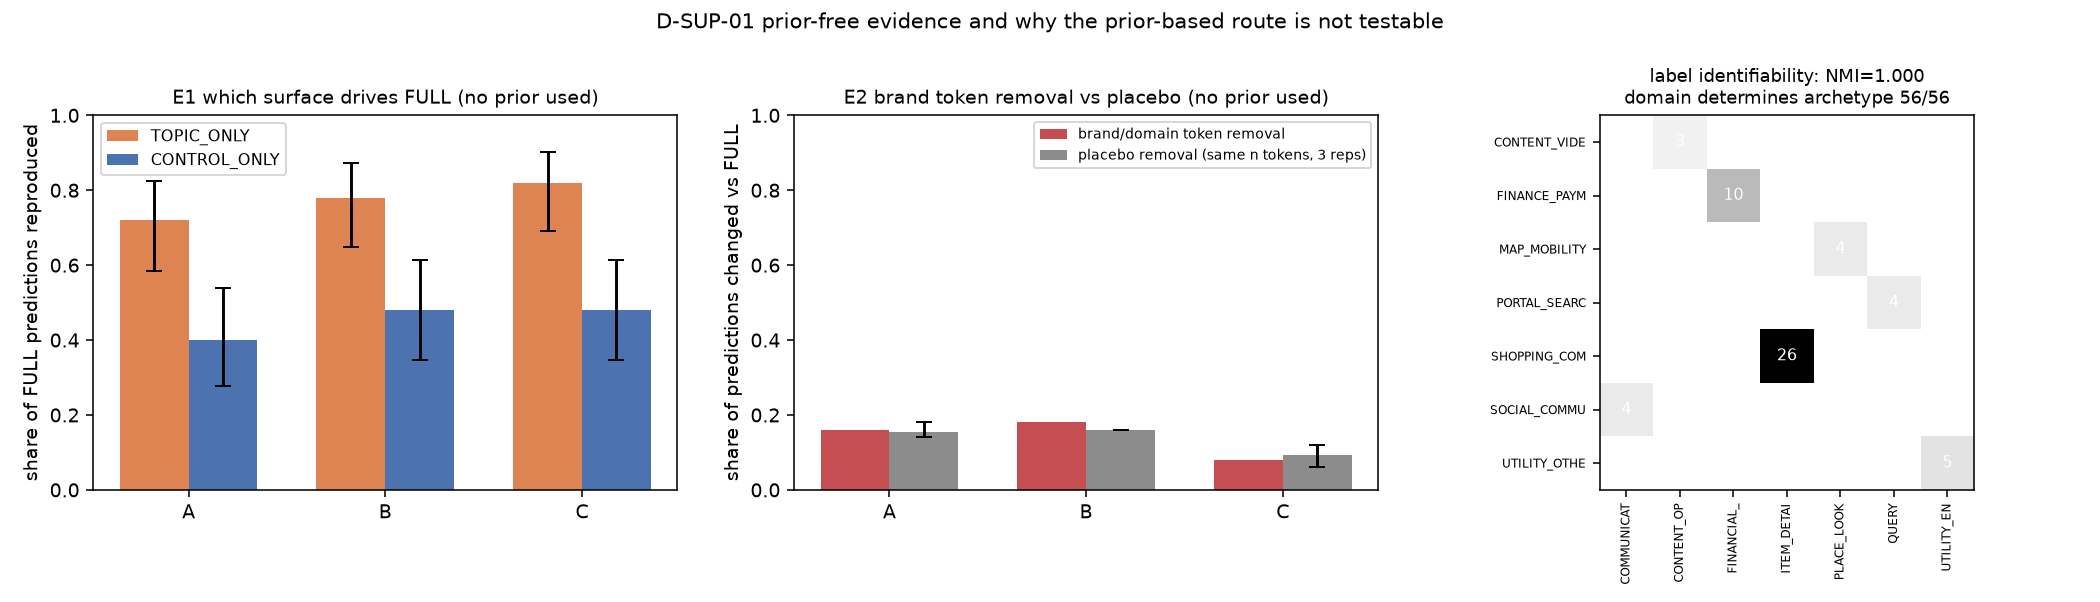

In [6]:
from IPython.display import Image, display as disp
disp(Image(filename=str(RD / "figures/DSUP01_priorfree_evidence.png")))

## 5. 판정 우선순위 지표 — stability → top-2 stability → margin → class coverage

In [7]:
s = R["prereg"]["primary_prototype_set"]
st = R["stability_across_representations"]["complete_case"][s]
pw = pd.DataFrame({k: {"top1_agreement": round(v["top1_agreement"], 3),
                       "n": v["top1_agreement_fraction"],
                       "cohen_kappa": round(v["top1_cohen_kappa"], 3),
                       "top2_set_agreement": round(v["top2_set_agreement"], 3)}
                   for k, v in st["pairwise"].items()}).T
display(pw.sort_values("top1_agreement", ascending=False))
u = st["unanimity"]
print(f"4-way top-1 만장일치 {u['four_way_top1_unanimity_fraction']} = "
      f"{u['four_way_top1_unanimity']:.3f}  Wilson95 "
      f"[{u['four_way_top1_unanimity_wilson95'][0]:.3f}, {u['four_way_top1_unanimity_wilson95'][1]:.3f}]")
print(f"4-way top-2 집합 만장일치 {u['four_way_top2_set_unanimity_fraction']} = "
      f"{u['four_way_top2_set_unanimity']:.3f}")
print("target 당 서로 다른 예측 개수 분포:", u["distinct_predictions_per_target_hist"],
      " 평균", round(u["mean_distinct_predictions_per_target"], 3))

,top1_agreement,n,cohen_kappa,top2_set_agreement
FULL~NO_BRAND_DOMAIN,0.84,42/50,0.788,0.72
FULL~TOPIC_ONLY,0.72,36/50,0.633,0.58
TOPIC_ONLY~NO_BRAND_DOMAIN,0.68,34/50,0.573,0.54
CONTROL_ONLY~NO_BRAND_DOMAIN,0.44,22/50,0.326,0.28
FULL~CONTROL_ONLY,0.4,20/50,0.281,0.22
CONTROL_ONLY~TOPIC_ONLY,0.32,16/50,0.193,0.16


4-way top-1 만장일치 15/50 = 0.300  Wilson95 [0.191, 0.438]
4-way top-2 집합 만장일치 6/50 = 0.120
target 당 서로 다른 예측 개수 분포: {'1': 15, '2': 24, '3': 11}  평균 1.92


In [8]:
rows = []
for r in ["FULL", "CONTROL_ONLY", "TOPIC_ONLY", "NO_BRAND_DOMAIN"]:
    cc = R["per_config"][f"{r}|{s}"]["complete_case"]
    pn = R["per_config"][f"{r}|{s}"]["permutation_null_complete_case"]
    rows.append({"representation": r,
                 "margin_median": round(cc["margin_median"], 4),
                 "class_coverage(7)": cc["n_distinct_predicted_classes"],
                 "never_predicted": ",".join(cc["never_predicted_classes"]) or "-",
                 "top2_prior_containment": round(cc["top2_prior_containment"], 3),
                 "macro_f1(diag)": round(cc["macro_f1"], 4),
                 "prior_agreement(diag)": round(cc["prior_agreement"], 4),
                 "perm_p": pn["perm_p_macro_f1"],
                 "tokens_median": R["token_stats"][r]["median"],
                 "n_empty": R["missing"]["n_empty_or_degenerate_by_representation"][r]})
display(pd.DataFrame(rows).set_index("representation"))
print("stratified p95 macro F1 (complete-case):",
      round(R["baselines"]["complete_case"]["stratified"]["macro_f1_p95"], 4),
      "| majority(참고용) macro F1:",
      round(R["baselines"]["complete_case"]["majority_reference"]["macro_f1"], 4))
print("주의: macro_f1 · prior_agreement 는 진단용이다.", R["target_variable"]["warning"])

,margin_median,class_coverage(7),never_predicted,top2_prior_containment,macro_f1(diag),prior_agreement(diag),perm_p,tokens_median,n_empty
representation,,,,,,,,,
FULL,0.0214,6,UTILITY_ENTRY,0.82,0.4747,0.64,0.00005,173.5,0
CONTROL_ONLY,0.0158,7,-,0.44,0.2600,0.32,0.00275,32.5,5
TOPIC_ONLY,0.0264,6,UTILITY_ENTRY,0.84,0.5009,0.66,0.00005,28.0,3
NO_BRAND_DOMAIN,0.0280,7,-,0.84,0.4298,0.64,0.00005,166.0,1


stratified p95 macro F1 (complete-case): 0.2238 | majority(참고용) macro F1: 0.0927
주의: macro_f1 · prior_agreement 는 진단용이다. gold label 이 아니라 business-domain prior 다. 지표 이름은 accuracy 가 아니라 prior_agreement 이며 diagnostic 으로만 쓴다. 더 강한 제약: 이 표본에서 prior_archetype 은 prior_business_domain 과 전단사(NMI=1.000, 56/56)이므로 prior_agreement 는 interaction 가설과 domain 가설을 원리적으로 구분하지 못한다. label_identifiability 참조.


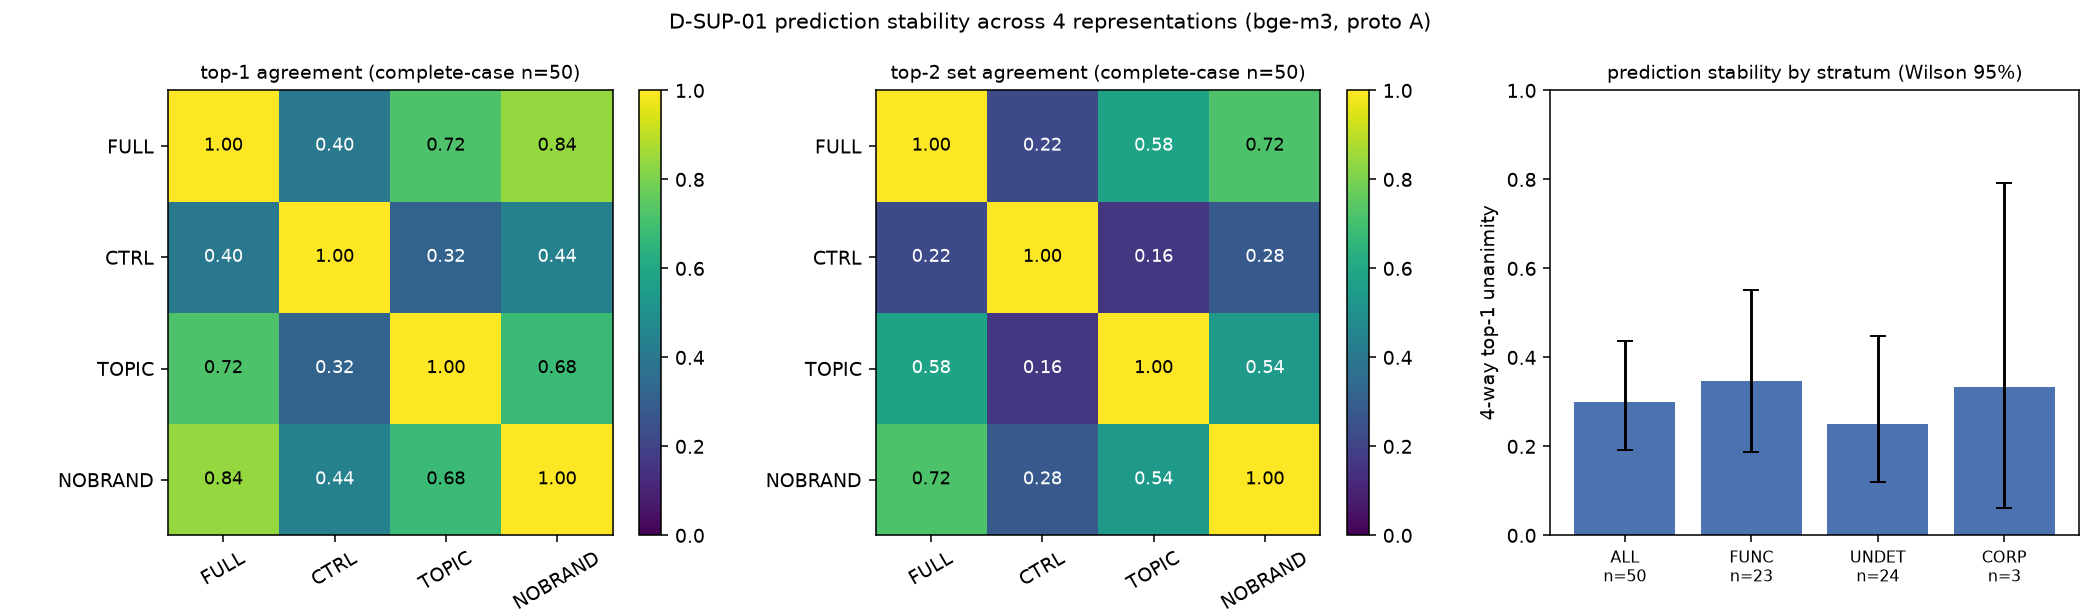

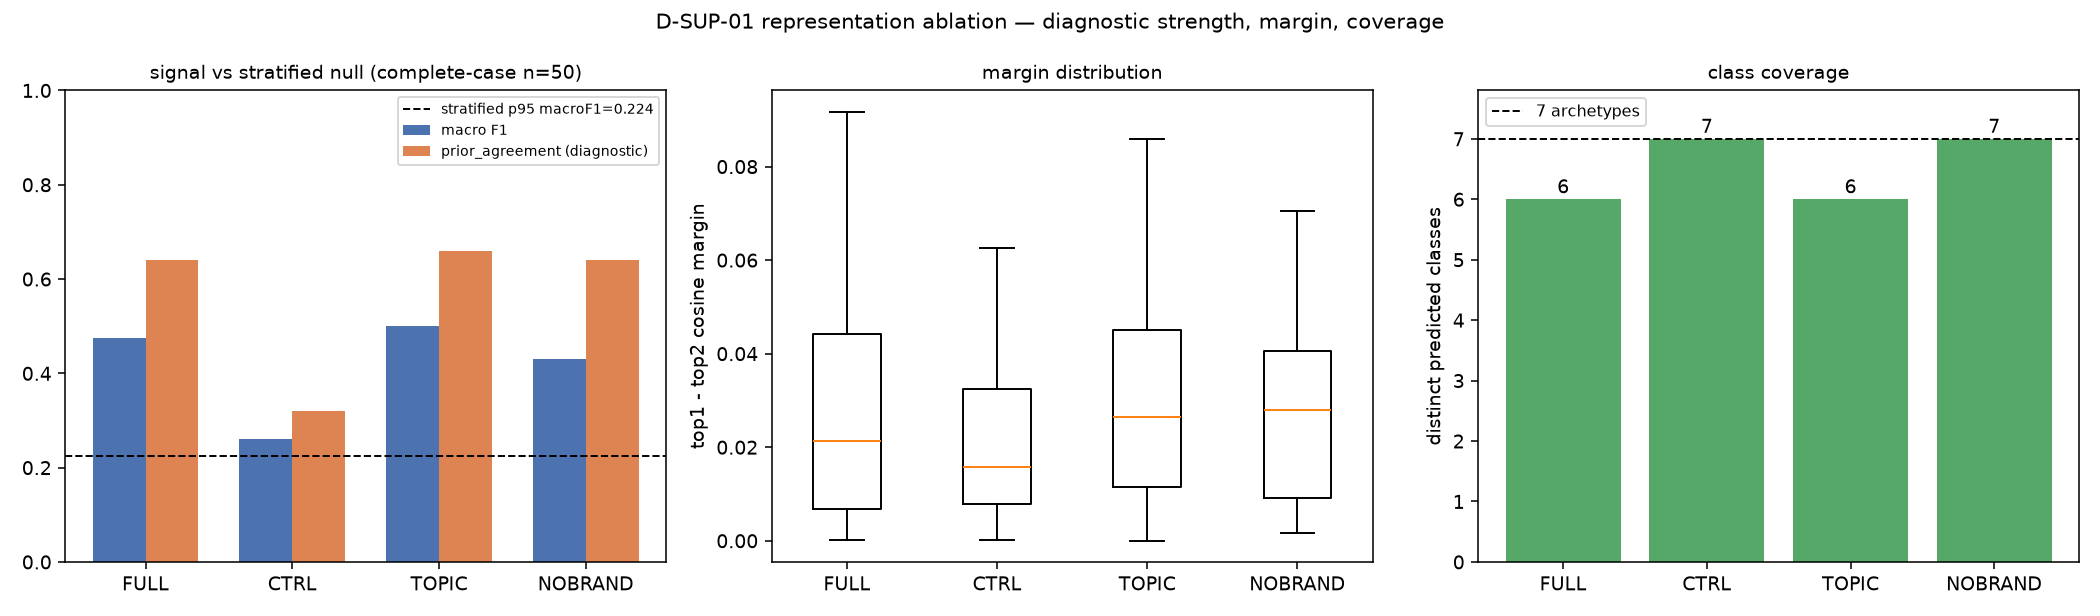

In [9]:
disp(Image(filename=str(RD / "figures/DSUP01_stability_matrix.png")))
disp(Image(filename=str(RD / "figures/DSUP01_signal_margin_coverage.png")))

## 6. prototype stability (문구 민감도)

,3way_unanimity,macro_f1_range,verdict_flip,kappa[A_SSOT_DEF~B_USER_BEHAVIOR],kappa[A_SSOT_DEF~C_TERSE_LABEL],kappa[B_USER_BEHAVIOR~C_TERSE_LABEL]
FULL,23/56,0.23,False,0.466,0.395,0.351
CONTROL_ONLY,23/51,0.104,False,0.423,0.463,0.465
TOPIC_ONLY,24/53,0.194,False,0.505,0.501,0.422
NO_BRAND_DOMAIN,22/55,0.243,False,0.39,0.49,0.285


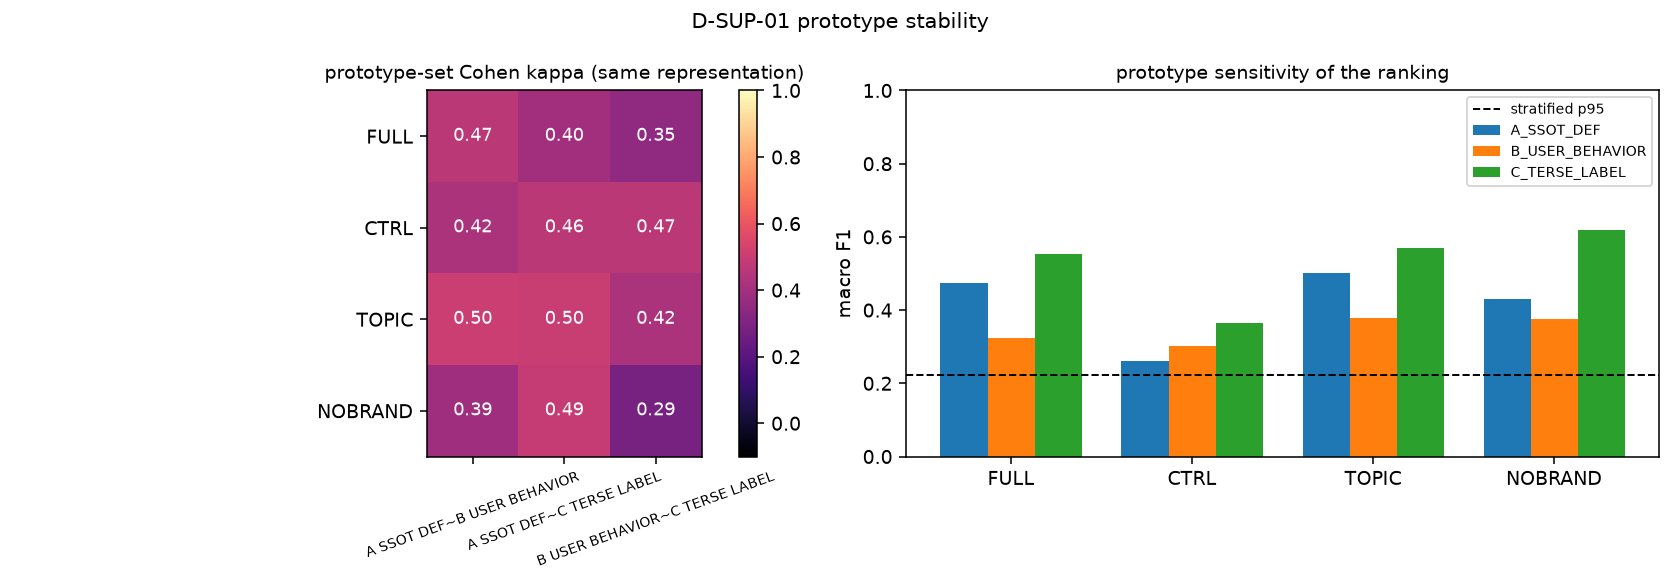

In [10]:
ps = pd.DataFrame({r: {"3way_unanimity": v["three_way_unanimity_fraction"],
                       "macro_f1_range": round(v["macro_f1_range"], 3),
                       "verdict_flip": v["verdict_flip_vs_stratified_p95"],
                       **{f"kappa[{k}]": round(x["cohen_kappa"], 3)
                          for k, x in v["pairwise"].items()}}
                   for r, v in R["prototype_stability"].items()}).T
display(ps)
disp(Image(filename=str(RD / "figures/DSUP01_prototype_stability.png")))

## 7. strata 분해 (RQ-D14 `identity_class`)

`CORPORATE_OR_APP_LANDING` 은 n=3 이라 **추정 불가에 가깝다** — 수치는 기록용이다.

n  prior_agreement        wilson95  \
stratum                  representation                                         
FUNCTIONAL_LANDING       FULL             23            0.696  [0.491, 0.844]   
                         CONTROL_ONLY     23            0.391  [0.222, 0.592]   
                         TOPIC_ONLY       23            0.783  [0.581, 0.903]   
                         NO_BRAND_DOMAIN  23            0.609  [0.408, 0.778]   
UNDETERMINED             FULL             24            0.583  [0.388, 0.755]   
                         CONTROL_ONLY     24            0.292  [0.149, 0.492]   
                         TOPIC_ONLY       24            0.583  [0.388, 0.755]   
                         NO_BRAND_DOMAIN  24            0.667  [0.467, 0.820]   
CORPORATE_OR_APP_LANDING FULL              3            0.667  [0.208, 0.939]   
                         CONTROL_ONLY      3            0.000  [0.000, 0.561]   
                         TOPIC_ONLY        3            0.333  [0.061, 0.792]   
                         NO_BRAND_DOMAIN   3            0.667  [0.208, 0.939]   

                                          macro_f1  coverage  margin_median  
stratum                  representation                                      
FUNCTIONAL_LANDING       FULL                0.390         5         0.0357  
                         CONTROL_ONLY        0.257         7         0.0228  
                         TOPIC_ONLY          0.440         5         0.0395  
                         NO_BRAND_DOMAIN     0.308         6         0.0333  
UNDETERMINED             FULL                0.483         5         0.0134  
                         CONTROL_ONLY        0.303         6         0.0155  
                         TOPIC_ONLY          0.492         5         0.0203  
                         NO_BRAND_DOMAIN     0.556         6         0.0221  
CORPORATE_OR_APP_LANDING FULL                0.143         2         0.0208  
                         CONTROL_ONLY        0.000         2         0.0118  
                         TOPIC_ONLY          0.095         3         0.0093  
                         NO_BRAND_DOMAIN     0.143         2         0.0251

FUNCTIONAL_LANDING         n=27  cc=23  n>=20, 구간추정 가능하나 여전히 소표본.
UNDETERMINED               n=26  cc=24  n>=20, 구간추정 가능하나 여전히 소표본.
CORPORATE_OR_APP_LANDING   n=3   cc=3   n=3 은 사실상 추정 불가에 가깝다. Wilson CI 폭이 거의 전 구간이라 어떤 순위 비교도 이 stratum 단독으로는 성립하지 않는다.


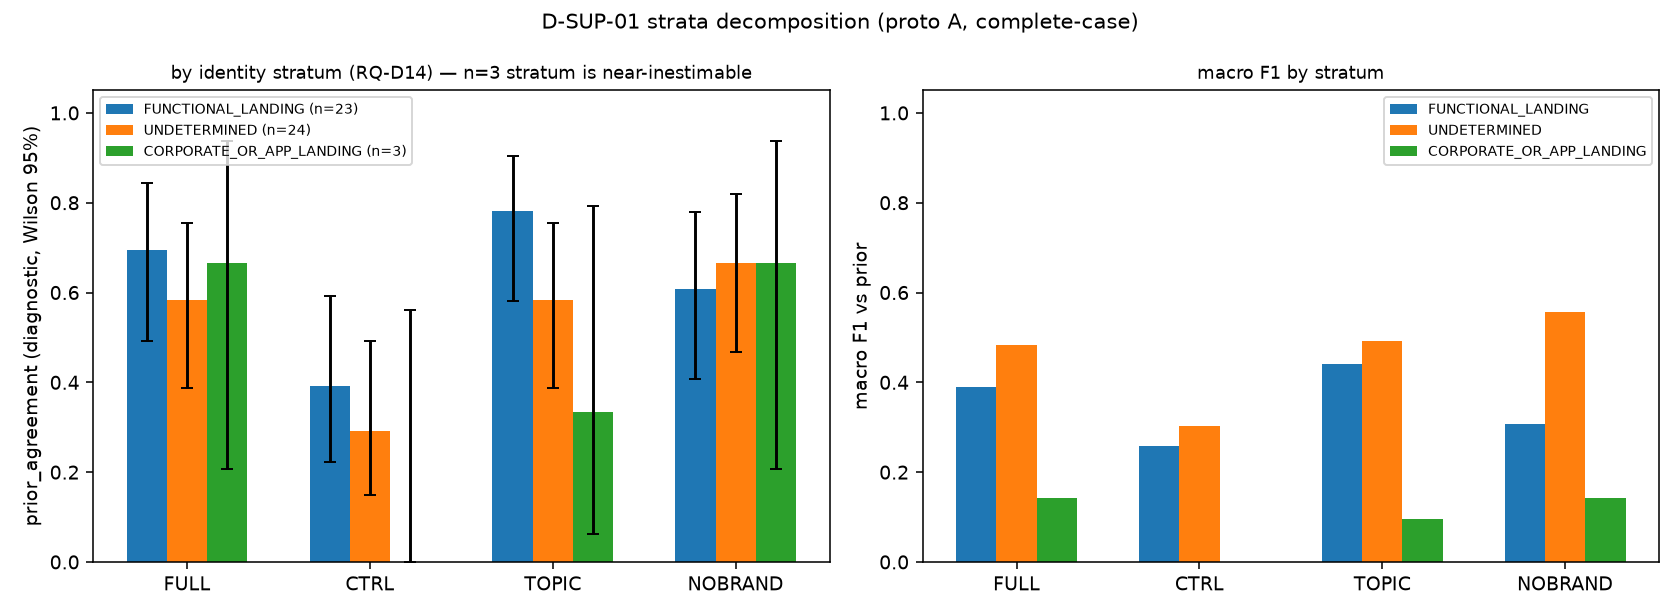

In [11]:
rows = []
for stn, v in R["by_strata"].items():
    for r, m in v["per_representation"].items():
        cc = m["complete_case"]
        if not cc.get("n"):
            continue
        lo, hi = cc["prior_agreement_wilson95"]
        rows.append({"stratum": stn, "n": cc["n"], "representation": r,
                     "prior_agreement": round(cc["prior_agreement"], 3),
                     "wilson95": f"[{lo:.3f}, {hi:.3f}]",
                     "macro_f1": round(cc["macro_f1"], 3),
                     "coverage": cc["n_distinct_predicted_classes"],
                     "margin_median": round(cc["margin_median"], 4)})
display(pd.DataFrame(rows).set_index(["stratum", "representation"]))
for stn, v in R["by_strata"].items():
    print(f"{stn:<26} n={v['n_all56']:<3} cc={v['n_complete_case']:<3} {v['estimability_note']}")
disp(Image(filename=str(RD / "figures/DSUP01_strata.png")))

## 8. 반례 · 기존 D 결과 재현 확인

In [12]:
ce = R["counterexamples"]
print("4개 representation 이 3개 이상 서로 다른 예측을 준 target:", ce["n_high_disagreement"])
display(pd.DataFrame([{**{"service": x["prior_service"], "prior": x["prior_archetype"],
                          "stratum": x["identity_class"]}, **x["predictions"]}
                      for x in ce["high_disagreement_targets"]]))
print("브랜드 제거로 예측이 뒤집힌 target:", ce["n_brand_removal_flips"])
display(pd.DataFrame(ce["brand_removal_flips"]))
print()
rc = R["replication_check_vs_RF2_C"]
print(rc["note"])
display(pd.DataFrame({"RF2-C 보고": rc["rf2c_reported"], "D-SUP-01 재계산": rc["dsup01_recomputed"]}))
print("필드 결합 순서 차이의 macro F1 영향:", round(rc["field_order_effect_on_macro_f1"], 5))

4개 representation 이 3개 이상 서로 다른 예측을 준 target: 11


,service,prior,stratum,FULL,CONTROL_ONLY,TOPIC_ONLY,NO_BRAND_DOMAIN
0,쿠팡이츠,ITEM_DETAIL,UNDETERMINED,COMMUNICATION_ENTRY,CONTENT_OPEN,ITEM_DETAIL,CONTENT_OPEN
1,디바이스 케어,UTILITY_ENTRY,UNDETERMINED,FINANCIAL_ACTION_ENTRY,COMMUNICATION_ENTRY,ITEM_DETAIL,FINANCIAL_ACTION_ENTRY
2,Netflix,CONTENT_OPEN,FUNCTIONAL_LANDING,CONTENT_OPEN,QUERY,CONTENT_OPEN,UTILITY_ENTRY
3,카카오톡,COMMUNICATION_ENTRY,UNDETERMINED,COMMUNICATION_ENTRY,QUERY,PLACE_LOOKUP,COMMUNICATION_ENTRY
4,네이버,QUERY,FUNCTIONAL_LANDING,ITEM_DETAIL,QUERY,CONTENT_OPEN,ITEM_DETAIL
5,탑마트,ITEM_DETAIL,CORPORATE_OR_APP_LANDING,ITEM_DETAIL,PLACE_LOOKUP,CONTENT_OPEN,ITEM_DETAIL
6,하나은행,FINANCIAL_ACTION_ENTRY,FUNCTIONAL_LANDING,FINANCIAL_ACTION_ENTRY,UTILITY_ENTRY,FINANCIAL_ACTION_ENTRY,ITEM_DETAIL
7,배달의민족,ITEM_DETAIL,UNDETERMINED,PLACE_LOOKUP,COMMUNICATION_ENTRY,PLACE_LOOKUP,ITEM_DETAIL
8,내 파일,UTILITY_ENTRY,UNDETERMINED,FINANCIAL_ACTION_ENTRY,COMMUNICATION_ENTRY,PLACE_LOOKUP,FINANCIAL_ACTION_ENTRY
9,11번가,ITEM_DETAIL,FUNCTIONAL_LANDING,PLACE_LOOKUP,QUERY,COMMUNICATION_ENTRY,COMMUNICATION_ENTRY


브랜드 제거로 예측이 뒤집힌 target: 8


,wtg,prior_service,prior_archetype,FULL,NO_BRAND_DOMAIN,n_removed_occurrences
0,054d78ed187cdd9f,쿠팡이츠,ITEM_DETAIL,COMMUNICATION_ENTRY,CONTENT_OPEN,10
1,13ed070478ef62c3,Netflix,CONTENT_OPEN,CONTENT_OPEN,UTILITY_ENTRY,12
2,8fd5d30f8b1d707b,하나은행,FINANCIAL_ACTION_ENTRY,FINANCIAL_ACTION_ENTRY,ITEM_DETAIL,7
3,a215c45b2cc585ca,에이닷 전화,UTILITY_ENTRY,COMMUNICATION_ENTRY,QUERY,12
4,c5285b96b598a08b,배달의민족,ITEM_DETAIL,PLACE_LOOKUP,ITEM_DETAIL,7
5,49a5eca8b58f7270,11번가,ITEM_DETAIL,PLACE_LOOKUP,COMMUNICATION_ENTRY,9
6,51484a735cdb487b,컴포즈커피,ITEM_DETAIL,QUERY,ITEM_DETAIL,5
7,ccb9754c97fa7341,현대백화점,ITEM_DETAIL,CONTENT_OPEN,COMMUNICATION_ENTRY,12



RF2-C(field ablation) 의 primary_controls 는 CONTROL_ONLY 와 필드 집합이 같고 결합 순서만 다르다(RF2-C: buttons,aria,form,placeholder,input / 여기: buttons,aria,placeholder,form,input). text_blob__ALL 은 FULL 과 동일 정의다. 재현 여부를 대조해 이 run 의 파이프라인이 기존 D 파이프라인과 어긋나지 않는지 확인한다.


,RF2-C 보고,D-SUP-01 재계산
primary_controls_macro_f1,0.2543,NaN
primary_controls_prior_agreement_all56,0.3036,NaN
text_blob_ALL_macro_f1,0.5088,NaN
text_blob_ALL_prior_agreement_all56,0.6786,NaN
source,results/RF2_C_field_ablation.json (읽기 전용 참조),NaN
CONTROL_ONLY_macro_f1_all56,NaN,0.258761
CONTROL_ONLY_prior_agreement_all56,NaN,0.303571
CONTROL_ONLY_RF2C_FIELD_ORDER_macro_f1_all56,NaN,0.254308
CONTROL_ONLY_RF2C_FIELD_ORDER_prior_agreement_all56,NaN,0.303571
FULL_macro_f1_all56,NaN,0.508777


필드 결합 순서 차이의 macro F1 영향: 0.00445


## 9. verdict · limitation · 추가 연구질문

In [13]:
print("VERDICT:", R["verdict"])
print(R["verdict_basis"])
print()
print("--- posthoc additions (선언) ---")
print(json.dumps(R["posthoc_additions"], ensure_ascii=False, indent=1))
print()
print("--- limitation ---")
print(R["limitation"])
print()
print("--- further questions ---")
for i, q in enumerate(R["further_questions"], 1):
    print(f"{i}. {q}")
print()
print("firewall:", R["firewall"]["not_opened"])
print("threshold/GO-NO-GO:", R["firewall"]["threshold_or_go_nogo"])

VERDICT: PARTIALLY_SUPPORTED
판정 근거는 prior 를 쓰지 않는 행동 비교(priorfree_evidence)다. prior 기반 경로(prior_agreement · macro F1)는 이 표본에서 prior_archetype 과 prior_business_domain 이 전단사(NMI=1.000, 56/56)라서 H-SUP01-INTERACTION 과 H-SUP01-DOMAIN 을 구분하지 못한다 → 그 경로는 NOT_TESTABLE. 사전등록된 prior 기반 판정은 삭제하지 않고 prereg_prior_based 아래에 그대로 보존한다.

--- posthoc additions (선언) ---
{
 "declared": true,
 "items": [
  "PLACEBO 제거 대조군(_PLACEBO_1..3)",
  "priorfree_evidence 절",
  "label_identifiability 절",
  "prior-free 재판정 층"
 ],
 "reason": "사전등록 이후, D orchestrator 가 검증한 구조적 사실(prior_archetype ≡ prior_business_domain 전단사)이 전달됐다. 이 사실은 사전등록된 prior 기반 판별 경로의 식별가능성을 무효화한다. 가설 4개와 representation 조작화 정의·prototype 문구는 하나도 바꾸지 않았고, 판정에 쓰는 증거 층만 추가했다.",
 "new_hypothesis_id": "H-SUP01-SIGNAL-SOURCE-PRIORFREE",
 "honesty_note": "prior-free 층의 임계값 중 0.25(브랜드 의존)·0.60(분리 가능)은 사전등록된 값을 그대로 재사용했다. placebo 대조와 McNemar 비교는 사전등록에 없던 추가 도구이며 exploratory 로 취급한다."
}

--- limitation ---
(0) 이 표본에서 prior_archetype 과 prior_business_domain 은 